# Procedural terrain: Monty prepares the data, three.js builds the scene

An agent asked for "a 3D island with trees" writes two programs, because each language has a job it is good at:

* **Python, in Monty** (pydantic's Python sandbox): the numbers. Layered value-noise terrain, an island falloff, a slope analysis, and tree placement on the slopes where trees would grow.
* **JavaScript, in pydeno** (a worker process behind an OS sandbox): the 3D. three.js turns the heightmap into a mesh, computes normals, paints vertices by height and slope, instances the trees, answers line-of-sight queries with a raycaster, and exports a binary glTF (`.glb`) any viewer opens.

Both halves run without trusting either: neither can touch your files, network or environment. The only things they can call are the host functions you hand them.

```
pip install pydeno pydantic-monty
```

In [1]:
from __future__ import annotations

import asyncio
import pathlib
import time
from typing import Any

from pydeno import WEB_POLYFILLS, IsolatedRuntime, RuntimeConfig
from pydantic_monty import Monty

The script calls `asyncio.run()` inside `TerrainPipeline.render`; a Jupyter kernel already runs its own event loop, so that call needs `nest_asyncio` patched in first. This cell has no equivalent in the script -- it exists only because a notebook kernel is async where a plain script process is not.

In [2]:
import nest_asyncio

nest_asyncio.apply()

Paths are relative to the repo root (this notebook's working directory), not to `__file__` as in the script version.

In [3]:
def _repo_root() -> pathlib.Path:
    """Walk up from the current directory to find the pydeno checkout: this notebook is run
    with the repo root as its cwd when executed from the command line, but opening it directly
    in Jupyter normally starts in its own directory (examples/notebooks/) instead."""
    for candidate in (pathlib.Path.cwd(), *pathlib.Path.cwd().parents):
        if (candidate / "vendor" / "libs").is_dir() and (candidate / "pyproject.toml").is_file():
            return candidate
    raise RuntimeError("run this notebook from inside a pydeno checkout")


REPO_ROOT = _repo_root()
LIBS = REPO_ROOT / "vendor" / "libs"
THREE_BUNDLE = "three-0.180.0-gltf.bundle.js"
assert (LIBS / THREE_BUNDLE).exists(), "run this notebook with cwd at the repo root"

The Python half (what the model wrote). It runs in Monty: no imports beyond `math`, no files.

In [4]:
MODEL_PYTHON = """
import math


def hash2(i, j, seed):
    h = (i * 374761393 + j * 668265263 + seed * 1274126177) % 4294967296
    h = ((h ^ (h >> 13)) * 1274126177) % 4294967296
    return (h % 100000) / 100000.0


def noise(x, y, seed):
    xi = math.floor(x)
    yi = math.floor(y)
    xf = x - xi
    yf = y - yi
    u = xf * xf * (3.0 - 2.0 * xf)
    v = yf * yf * (3.0 - 2.0 * yf)
    a = hash2(xi, yi, seed)
    b = hash2(xi + 1, yi, seed)
    c = hash2(xi, yi + 1, seed)
    d = hash2(xi + 1, yi + 1, seed)
    return a + (b - a) * u + (c - a) * v + (a - b - c + d) * u * v


heights = []
for j in range(N):
    for i in range(N):
        x = i / (N - 1)
        y = j / (N - 1)
        h = 0.0
        amp = 1.0
        freq = 4.0
        norm = 0.0
        for octave in range(4):
            h += amp * noise(x * freq, y * freq, octave + 7)
            norm += amp
            amp *= 0.5
            freq *= 2.0
        dx = x - 0.5
        dy = y - 0.5
        falloff = 1.0 - min(1.0, math.sqrt(dx * dx + dy * dy) * 2.0)
        heights.append(round(h / norm * falloff * 32.0, 3))

# Trees grow on gentle slopes between the beach and the snow line.
step = max(2, N // 24)
trees = []
for j in range(1, N - 1, step):
    for i in range(1, N - 1, step):
        here = heights[j * N + i]
        slope = max(
            abs(heights[j * N + i + 1] - here),
            abs(heights[j * N + i - 1] - here),
            abs(heights[(j + 1) * N + i] - here),
            abs(heights[(j - 1) * N + i] - here),
        )
        jitter = hash2(i, j, 99)
        if 2.0 < here < 15.0 and slope < 0.9 and jitter > 0.35:
            trees.append([round(i / (N - 1), 4), round(j / (N - 1), 4)])

{
    "n": N,
    "heights": heights,
    "trees": trees,
    "min": min(heights),
    "max": max(heights),
    "mean": round(sum(heights) / len(heights), 3),
}
"""

The JavaScript half. It runs in pydeno with three.js loaded; `getTerrain()` is the host function that hands it the Python result, and the only way in.

In [5]:
MODEL_JAVASCRIPT = """
globalThis.buildScene = (losQueries) => {
  const { n, heights, trees } = getTerrain();
  const size = 100;

  const geo = new THREE.PlaneGeometry(size, size, n - 1, n - 1);
  geo.rotateX(-Math.PI / 2);
  const pos = geo.attributes.position;
  for (let k = 0; k < pos.count; k++) pos.setY(k, heights[k]);
  geo.computeVertexNormals();

  // Paint by height and slope: sand, grass, rock, snow.
  const normal = geo.attributes.normal;
  const colors = new Float32Array(pos.count * 3);
  for (let k = 0; k < pos.count; k++) {
    const h = heights[k], slope = 1 - normal.getY(k);
    let r = 0.2, g = 0.5, b = 0.2;
    if (h < 2) { r = 0.76; g = 0.7; b = 0.5; }
    else if (h > 22) { r = 0.95; g = 0.95; b = 0.97; }
    else if (slope > 0.2 || h > 16) { r = 0.45; g = 0.42; b = 0.4; }
    colors.set([r, g, b], k * 3);
  }
  geo.setAttribute('color', new THREE.BufferAttribute(colors, 3));
  const terrain = new THREE.Mesh(geo, new THREE.MeshStandardMaterial({ vertexColors: true }));

  // Trees: one instanced cone, each placed on the surface by a bilinear lookup of the heightmap.
  const at = (u, v) => {
    const x = u * (n - 1), z = v * (n - 1);
    const i = Math.min(n - 2, Math.floor(x)), j = Math.min(n - 2, Math.floor(z));
    const fx = x - i, fz = z - j, H = (a, b) => heights[b * n + a];
    return H(i, j) * (1 - fx) * (1 - fz) + H(i + 1, j) * fx * (1 - fz)
         + H(i, j + 1) * (1 - fx) * fz + H(i + 1, j + 1) * fx * fz;
  };
  const cone = new THREE.ConeGeometry(0.7, 2.6, 6);
  const forest = new THREE.InstancedMesh(cone, new THREE.MeshStandardMaterial({ color: 0x1f6f3a }), trees.length);
  const m = new THREE.Matrix4();
  trees.forEach(([u, v], k) => {
    m.setPosition((u - 0.5) * size, at(u, v) + 1.3, (v - 0.5) * size);
    forest.setMatrixAt(k, m);
  });

  const scene = new THREE.Scene();
  scene.add(terrain, forest);
  scene.updateMatrixWorld(true);
  globalThis.__scene = scene;

  // Line of sight between pairs of points, answered by raycasting the real mesh.
  const ray = new THREE.Raycaster();
  let clear = 0;
  for (let q = 0; q < losQueries; q++) {
    const a = new THREE.Vector3(-35 + q * 3, 40, -30), b = new THREE.Vector3(30, 5 + q, 35 - q * 2);
    const d = b.clone().sub(a);
    ray.set(a, d.clone().normalize());
    ray.far = d.length();
    if (ray.intersectObject(terrain).length === 0) clear++;
  }

  // Surface area and the bounding box.
  let area = 0;
  const idx = geo.index, p = geo.attributes.position, ta = new THREE.Triangle();
  const va = new THREE.Vector3(), vb = new THREE.Vector3(), vc = new THREE.Vector3();
  for (let t = 0; t < idx.count; t += 3) {
    ta.set(va.fromBufferAttribute(p, idx.getX(t)), vb.fromBufferAttribute(p, idx.getX(t + 1)),
           vc.fromBufferAttribute(p, idx.getX(t + 2)));
    area += ta.getArea();
  }
  const box = new THREE.Box3().setFromObject(terrain);
  return {
    triangles: idx.count / 3, trees: trees.length, surfaceArea: Math.round(area),
    height: [box.min.y, box.max.y], lineOfSightClear: clear, lineOfSightQueries: losQueries,
  };
};

globalThis.exportGlb = () => new Promise((resolve, reject) =>
  new GLTFExporter().parse(globalThis.__scene, resolve, reject, { binary: true }));
"""

One Monty pool and one warm pydeno runtime, reused across scenes.

In [6]:
class TerrainPipeline:
    """One Monty pool and one warm pydeno runtime, reused across scenes."""

    def __init__(self, *, jitless: bool = True) -> None:
        self.monty = Monty().__enter__()
        self.rt = IsolatedRuntime(
            RuntimeConfig(bootstrap=WEB_POLYFILLS, timeout=120.0),
            sandbox="require",
            request_timeout=300,
            jitless=jitless,
        )
        self._terrain: dict[str, Any] = {}
        self.rt.bind_function("getTerrain", lambda: self._terrain)
        self.load_seconds = 0.0

    def load_three(self) -> None:
        start = time.perf_counter()
        self.rt.eval((LIBS / THREE_BUNDLE).read_text() + "\n;0")
        self.rt.eval(MODEL_JAVASCRIPT + "\n;0")
        self.load_seconds = time.perf_counter() - start

    def prepare(self, n: int) -> dict[str, Any]:
        """Python half, in Monty."""
        with self.monty.checkout() as session:
            return session.feed_run(MODEL_PYTHON, inputs={"N": n})

    def render(
        self, n: int, los_queries: int = 8
    ) -> tuple[bytes, dict[str, Any], dict[str, float]]:
        t0 = time.perf_counter()
        self._terrain = self.prepare(n)
        t1 = time.perf_counter()
        stats = self.rt.eval(f"buildScene({los_queries})")
        t2 = time.perf_counter()
        glb = asyncio.run(self.rt.eval_async("exportGlb()", timeout=300))
        t3 = time.perf_counter()
        return (
            bytes(glb),
            stats,
            {
                "monty_prepare": t1 - t0,
                "three_build": t2 - t1,
                "glb_export": t3 - t2,
                "total": t3 - t0,
            },
        )

    def close(self) -> None:
        self.rt.close()
        self.monty.__exit__(None, None, None)

Run it: load three.js into the sandbox, build the heightmap in Monty, build the mesh and export the `.glb` in pydeno.

In [7]:
n = 129
pipe = TerrainPipeline()
try:
    print(f"sandbox: {pipe.rt.sandbox}")
    pipe.load_three()
    print(f"three.js loaded into the sandbox in {pipe.load_seconds * 1000:.0f} ms")
    glb, stats, t = pipe.render(n)
    pathlib.Path("terrain.glb").write_bytes(glb)
    print(
        f"{n}x{n} grid -> {stats['triangles']} triangles, {stats['trees']} trees, "
        f"{stats['lineOfSightClear']}/{stats['lineOfSightQueries']} lines of sight clear"
    )
    print(f"  monty prepared the data   {t['monty_prepare'] * 1000:8.0f} ms")
    print(f"  three.js built the scene  {t['three_build'] * 1000:8.0f} ms")
    print(f"  glTF export               {t['glb_export'] * 1000:8.0f} ms")
    print(
        f"wrote terrain.glb ({len(glb) / 1024:.0f} KiB) in {t['total'] * 1000:.0f} ms total"
    )
finally:
    pipe.close()

sandbox: seatbelt
three.js loaded into the sandbox in 28 ms


129x129 grid -> 32768 triangles, 253 trees, 8/8 lines of sight clear
  monty prepared the data        162 ms
  three.js built the scene       617 ms
  glTF export                     97 ms
wrote terrain.glb (921 KiB) in 876 ms total


The `.glb` is a binary glTF scene; it isn't rendered inline here. Below: confirm it was written, then show the pre-rendered preview used in the docs gallery.

In [8]:
glb_path = pathlib.Path("terrain.glb")
assert glb_path.exists(), "terrain.glb was not written"
glb_size = glb_path.stat().st_size
print(f"wrote {glb_path} ({glb_size} bytes, {glb_size / 1024:.1f} KiB)")

wrote terrain.glb (943200 bytes, 921.1 KiB)


A green island with instanced pine trees and grey rock on steep slopes, on a sand-coloured plane.

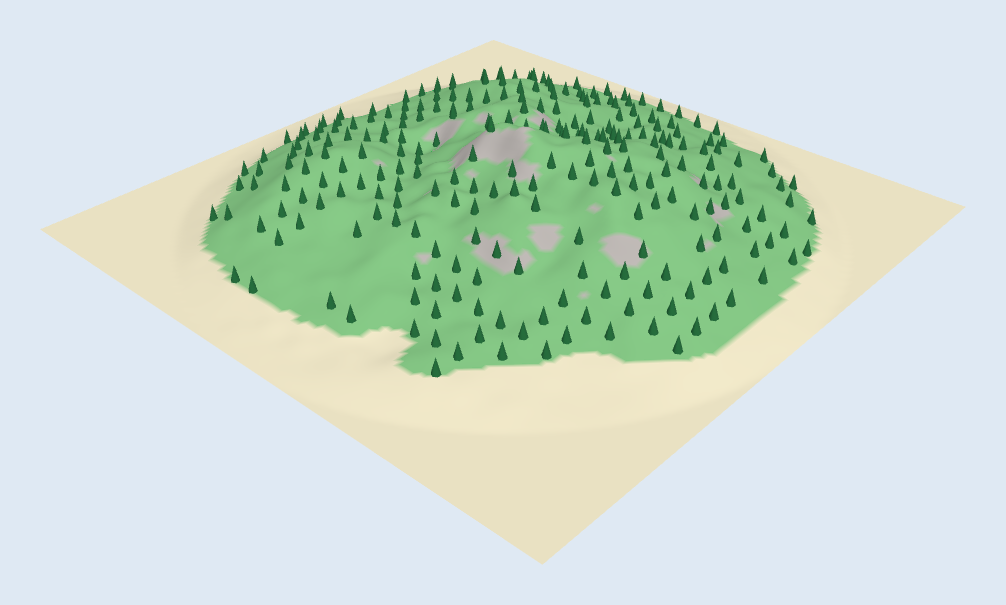

In [9]:
from IPython.display import Image, display

display(Image(filename=str(REPO_ROOT / "docs" / "assets" / "examples" / "monty_three_terrain.png")))